In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import time
import warnings
warnings.filterwarnings('ignore')


#!pip install prophet

from prophet import Prophet

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.tools.eval_measures import rmse

In [2]:
df = pd.read_csv("forecast train.csv")

df['date'] = pd.to_datetime(df['date'])


### fbProphet

Prophet is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects. 
It works best with time series that have strong seasonal effects and several seasons of historical data.

In [10]:

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_df = store_i.to_frame()
    store_i_df['ds'] = store_i_df.index
    store_i_df.columns = ['y','ds']
    store_i_model = Prophet(yearly_seasonality=True)
    store_i_model.fit(store_i_df)
    store_i_future = store_i_model.make_future_dataframe(periods=12,freq='MS')
    #store_i_future
    store_i_forecast = store_i_model.predict(store_i_future)
    #store_i_forecast
    metric_df_i = store_i_forecast.set_index('ds')[['yhat']].join(store_i_df.set_index('ds').y).reset_index()
    metric_df_i.dropna(inplace=True)
    print('rmse of store' +str(i)+':',rmse(metric_df_i.y, metric_df_i.yhat))

16:56:47 - cmdstanpy - INFO - Chain [1] start processing
16:56:47 - cmdstanpy - INFO - Chain [1] done processing
16:56:48 - cmdstanpy - INFO - Chain [1] start processing


rmse of store1: 57.33522247727067


16:56:48 - cmdstanpy - INFO - Chain [1] done processing
16:56:48 - cmdstanpy - INFO - Chain [1] start processing


rmse of store2: 81.51222610487261


16:56:49 - cmdstanpy - INFO - Chain [1] done processing
16:56:49 - cmdstanpy - INFO - Chain [1] start processing


...

rmse of store8: 75.96172058834054


16:56:52 - cmdstanpy - INFO - Chain [1] done processing
16:56:53 - cmdstanpy - INFO - Chain [1] start processing


rmse of store9: 64.79600460681706


16:56:53 - cmdstanpy - INFO - Chain [1] done processing


rmse of store10: 69.01518166887772


The predict method will assign each row in future a predicted value which it names yhat. 
The ds (date stamp) column should be of a format expected by Pandas, ideally YYYY-MM-DD HH:MM:SS for a time stamp.

17:08:09 - cmdstanpy - INFO - Chain [1] start processing
17:08:09 - cmdstanpy - INFO - Chain [1] done processing
17:08:12 - cmdstanpy - INFO - Chain [1] start processing
17:08:12 - cmdstanpy - INFO - Chain [1] done processing
17:08:12 - cmdstanpy - INFO - Chain [1] start processing
17:08:13 - cmdstanpy - INFO - Chain [1] done processing
17:08:13 - cmdstanpy - INFO - Chain [1] start processing
17:08:14 - cmdstanpy - INFO - Chain [1] done processing
17:08:14 - cmdstanpy - INFO - Chain [1] start processing
17:08:14 - cmdstanpy - INFO - Chain [1] done processing
17:08:15 - cmdstanpy - INFO - Chain [1] start processing
17:08:15 - cmdstanpy - INFO - Chain [1] done processing
17:08:16 - cmdstanpy - INFO - Chain [1] start processing
17:08:16 - cmdstanpy - INFO - Chain [1] done processing
17:08:16 - cmdstanpy - INFO - Chain [1] start processing
17:08:17 - cmdstanpy - INFO - Chain [1] done processing
17:08:17 - cmdstanpy - INFO - Chain [1] start processing
17:08:18 - cmdstanpy - INFO - Chain [1]

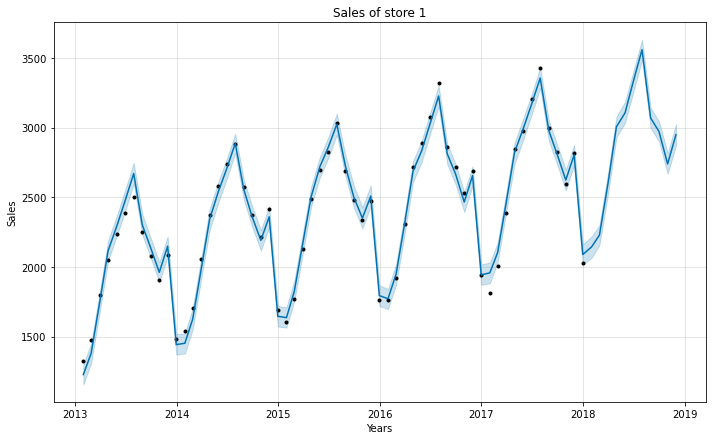

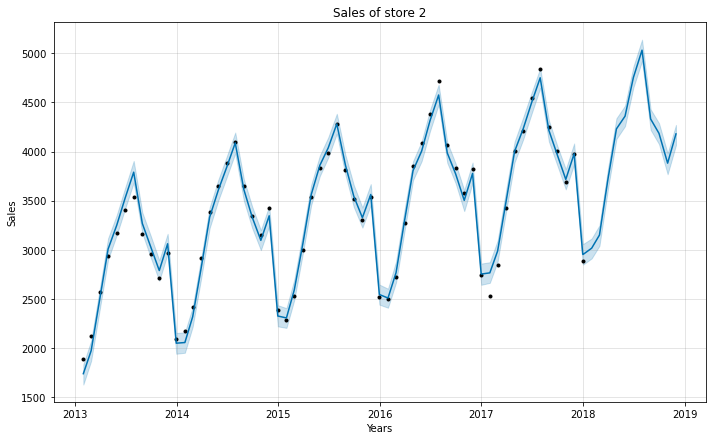

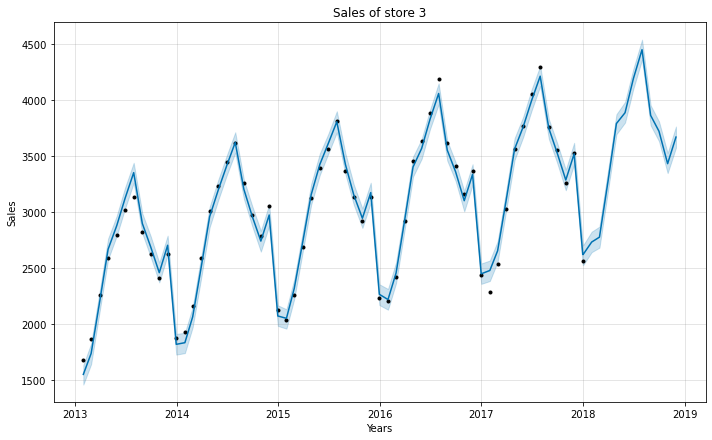

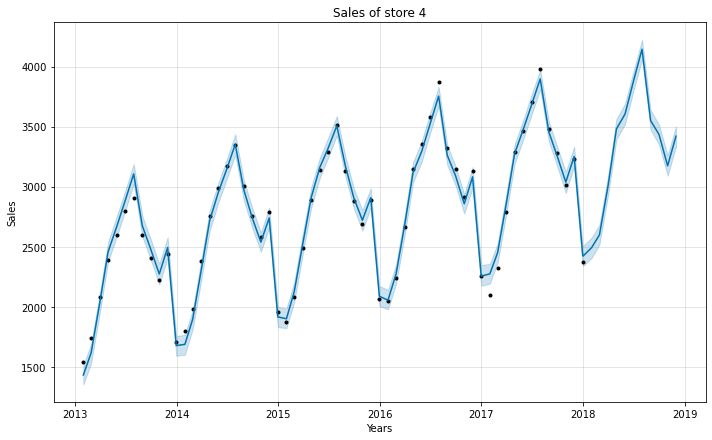

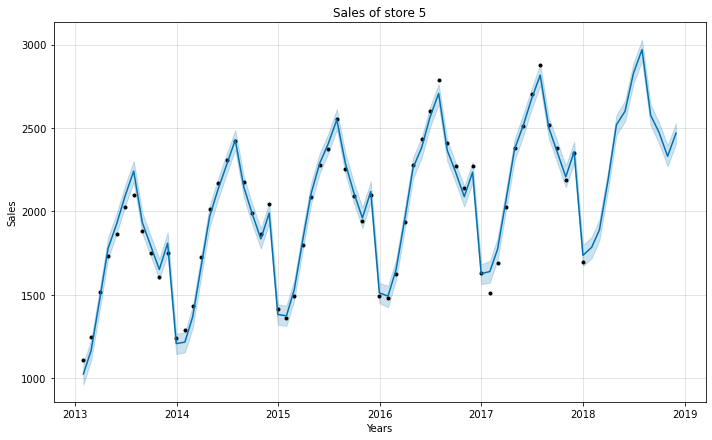

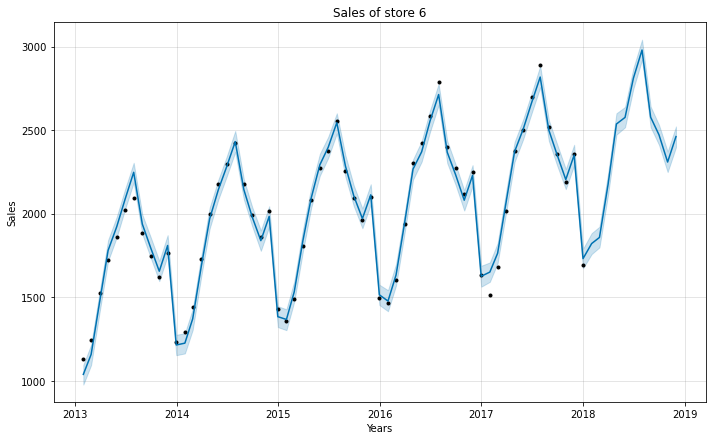

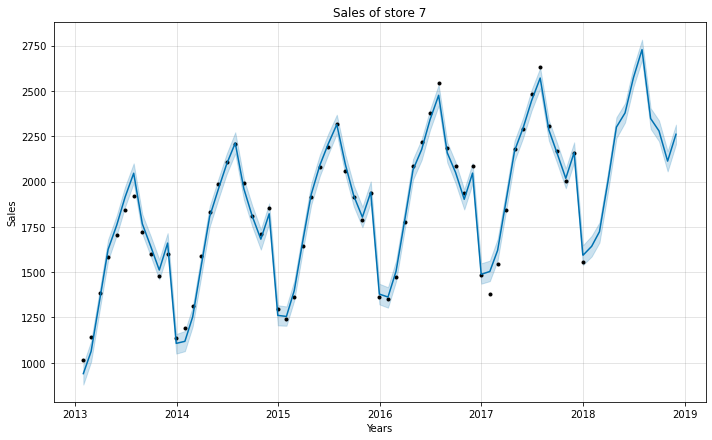

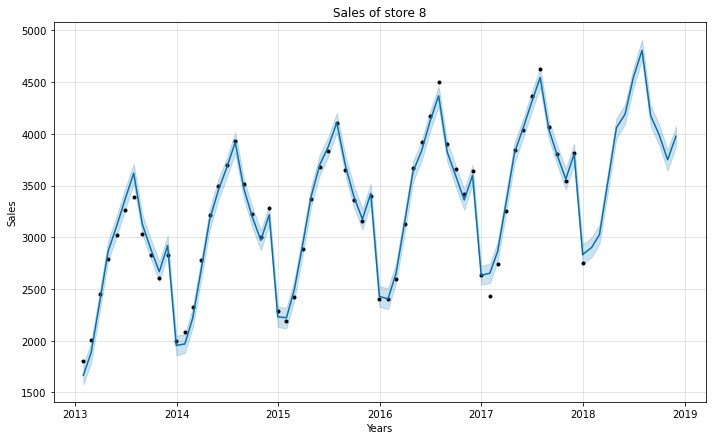

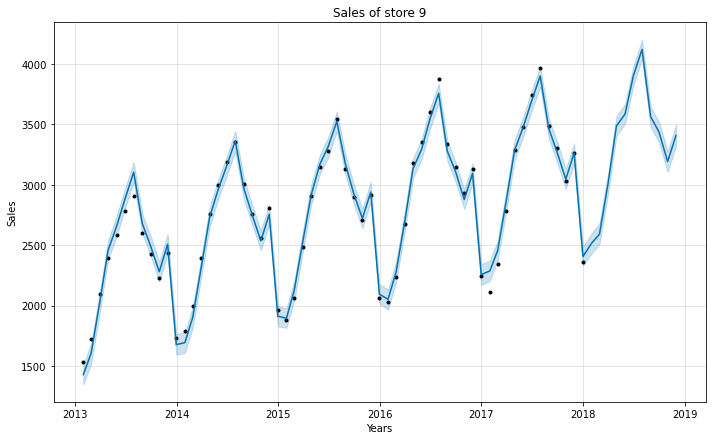

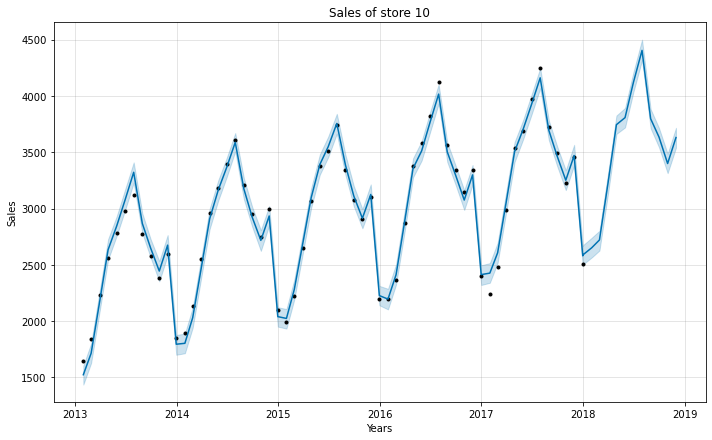

In [12]:

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_df = store_i.to_frame()
    store_i_df['ds'] = store_i_df.index
    store_i_df.columns = ['y','ds']
    store_i_model = Prophet(yearly_seasonality=True)
    store_i_model.fit(store_i_df)
    store_i_future = store_i_model.make_future_dataframe(periods=12,freq='MS')
    #store_i_future
    store_i_forecast = store_i_model.predict(store_i_future)
    #store_i_forecast
    store_i_model.plot(store_i_forecast);
    plt.title('Sales of store '+str(i))
    plt.xlabel('Years')
    plt.ylabel('Sales')

In [17]:
from prophet.plot import plot_plotly, plot_components_plotly



for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_df = store_i.to_frame()
    store_i_df['ds'] = store_i_df.index
    store_i_df.columns = ['y','ds']
    store_i_model = Prophet(yearly_seasonality=True)
    store_i_model.fit(store_i_df)
    store_i_future = store_i_model.make_future_dataframe(periods=12,freq='MS')
    #store_i_future
    store_i_forecast = store_i_model.predict(store_i_future)
    #store_i_forecast
    plot_plotly(store_i_model, store_i_forecast)
    plt.show()

17:12:30 - cmdstanpy - INFO - Chain [1] start processing
17:12:30 - cmdstanpy - INFO - Chain [1] done processing
17:12:30 - cmdstanpy - INFO - Chain [1] start processing
17:12:31 - cmdstanpy - INFO - Chain [1] done processing
17:12:31 - cmdstanpy - INFO - Chain [1] start processing
17:12:32 - cmdstanpy - INFO - Chain [1] done processing
17:12:32 - cmdstanpy - INFO - Chain [1] start processing
17:12:32 - cmdstanpy - INFO - Chain [1] done processing
17:12:32 - cmdstanpy - INFO - Chain [1] start processing
17:12:33 - cmdstanpy - INFO - Chain [1] done processing
17:12:33 - cmdstanpy - INFO - Chain [1] start processing
17:12:34 - cmdstanpy - INFO - Chain [1] done processing
17:12:34 - cmdstanpy - INFO - Chain [1] start processing
17:12:34 - cmdstanpy - INFO - Chain [1] done processing
17:12:34 - cmdstanpy - INFO - Chain [1] start processing
17:12:35 - cmdstanpy - INFO - Chain [1] done processing
17:12:35 - cmdstanpy - INFO - Chain [1] start processing
17:12:35 - cmdstanpy - INFO - Chain [1]

17:10:19 - cmdstanpy - INFO - Chain [1] start processing
17:10:20 - cmdstanpy - INFO - Chain [1] done processing
17:10:20 - cmdstanpy - INFO - Chain [1] start processing
17:10:20 - cmdstanpy - INFO - Chain [1] done processing
17:10:21 - cmdstanpy - INFO - Chain [1] start processing
17:10:21 - cmdstanpy - INFO - Chain [1] done processing
17:10:21 - cmdstanpy - INFO - Chain [1] start processing
17:10:22 - cmdstanpy - INFO - Chain [1] done processing
17:10:22 - cmdstanpy - INFO - Chain [1] start processing
17:10:22 - cmdstanpy - INFO - Chain [1] done processing
17:10:23 - cmdstanpy - INFO - Chain [1] start processing
17:10:23 - cmdstanpy - INFO - Chain [1] done processing
17:10:23 - cmdstanpy - INFO - Chain [1] start processing
17:10:24 - cmdstanpy - INFO - Chain [1] done processing
17:10:24 - cmdstanpy - INFO - Chain [1] start processing
17:10:24 - cmdstanpy - INFO - Chain [1] done processing
17:10:25 - cmdstanpy - INFO - Chain [1] start processing
17:10:25 - cmdstanpy - INFO - Chain [1]

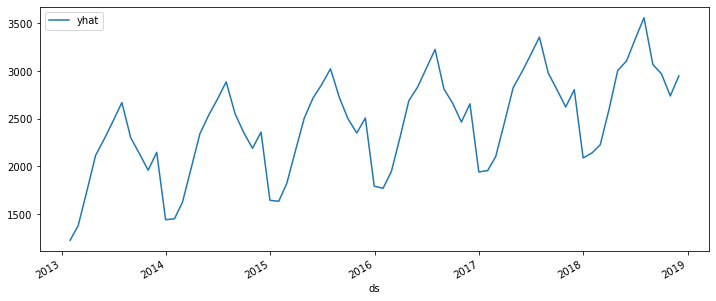

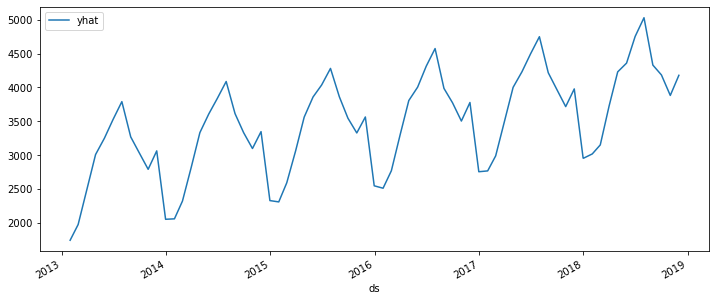

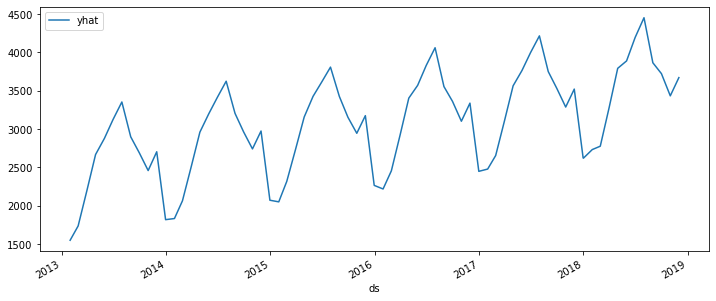

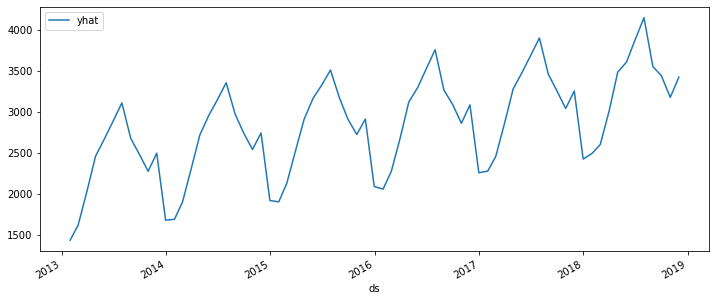

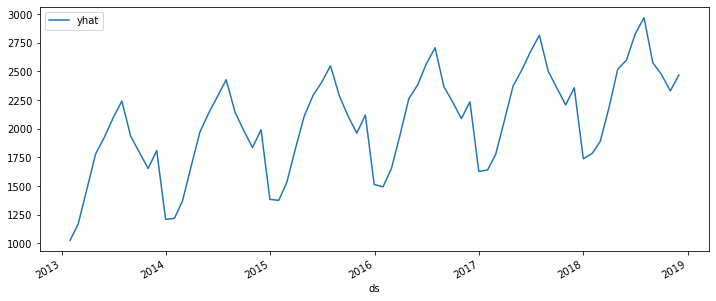

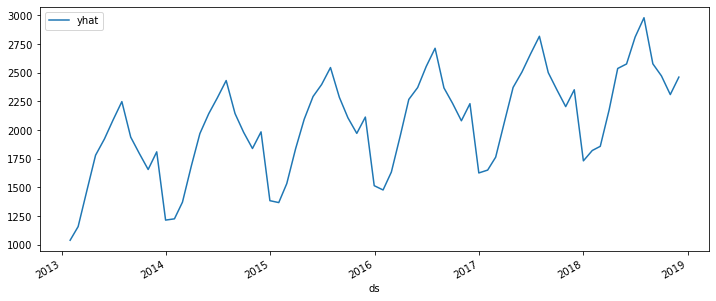

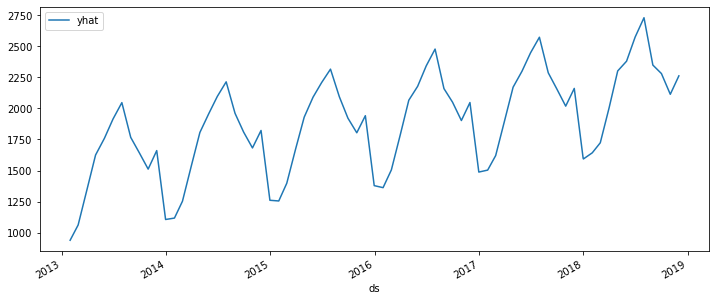

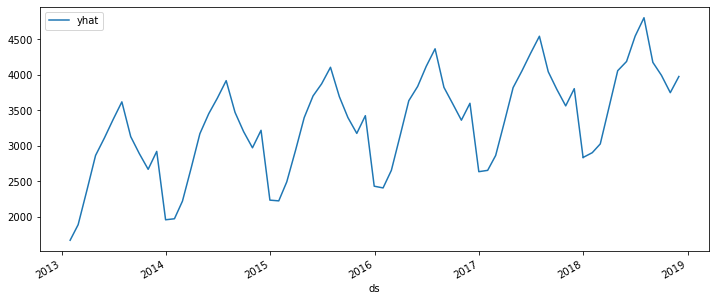

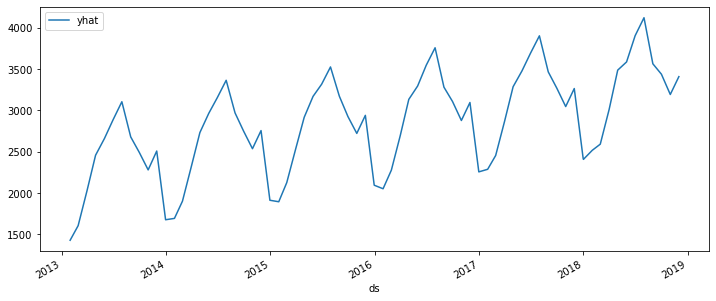

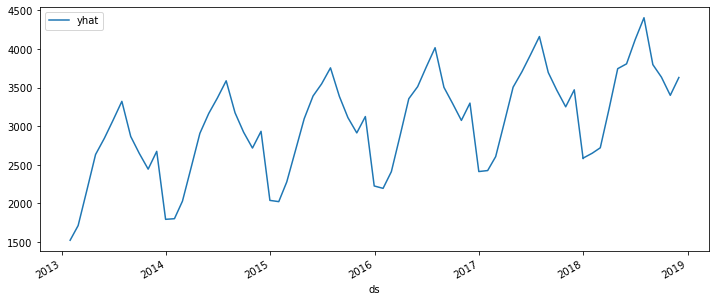

In [14]:

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_df = store_i.to_frame()
    store_i_df['ds'] = store_i_df.index
    store_i_df.columns = ['y','ds']
    store_i_model = Prophet(yearly_seasonality=True)
    store_i_model.fit(store_i_df)
    store_i_future = store_i_model.make_future_dataframe(periods=12,freq='MS')
    #store_i_future
    store_i_forecast = store_i_model.predict(store_i_future)
    #store_i_forecast
    store_i_forecast.plot(x='ds',y='yhat',figsize=(12,5))

17:11:42 - cmdstanpy - INFO - Chain [1] start processing
17:11:42 - cmdstanpy - INFO - Chain [1] done processing
17:11:43 - cmdstanpy - INFO - Chain [1] start processing
17:11:44 - cmdstanpy - INFO - Chain [1] done processing
17:11:44 - cmdstanpy - INFO - Chain [1] start processing
17:11:44 - cmdstanpy - INFO - Chain [1] done processing
17:11:45 - cmdstanpy - INFO - Chain [1] start processing
17:11:46 - cmdstanpy - INFO - Chain [1] done processing
17:11:46 - cmdstanpy - INFO - Chain [1] start processing
17:11:47 - cmdstanpy - INFO - Chain [1] done processing
17:11:47 - cmdstanpy - INFO - Chain [1] start processing
17:11:48 - cmdstanpy - INFO - Chain [1] done processing
17:11:48 - cmdstanpy - INFO - Chain [1] start processing
17:11:49 - cmdstanpy - INFO - Chain [1] done processing
17:11:49 - cmdstanpy - INFO - Chain [1] start processing
17:11:49 - cmdstanpy - INFO - Chain [1] done processing
17:11:50 - cmdstanpy - INFO - Chain [1] start processing
17:11:50 - cmdstanpy - INFO - Chain [1]

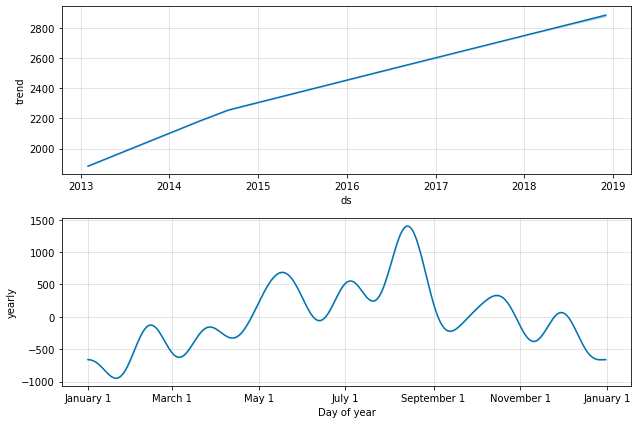

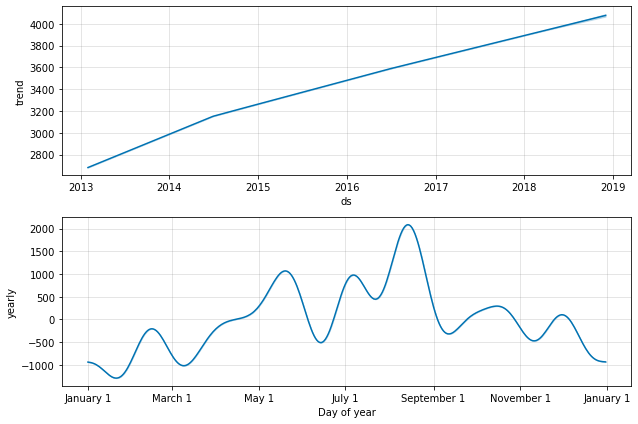

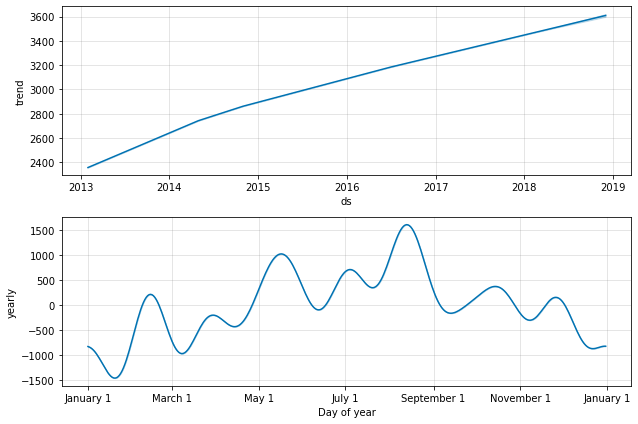

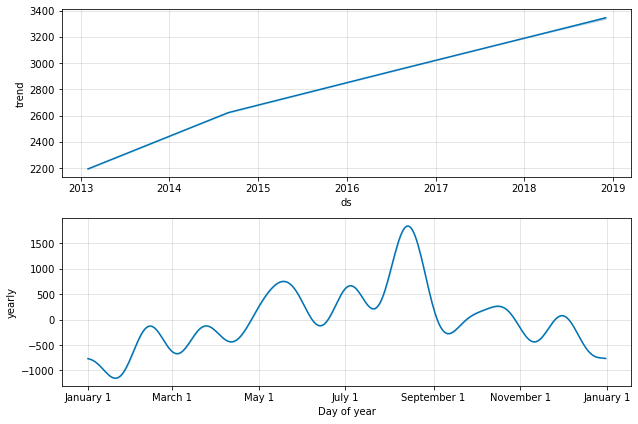

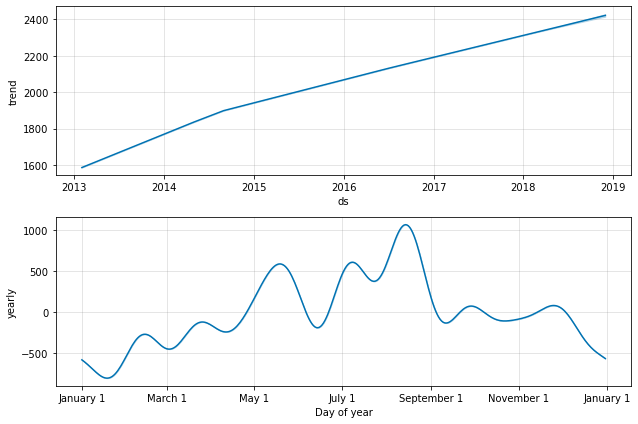

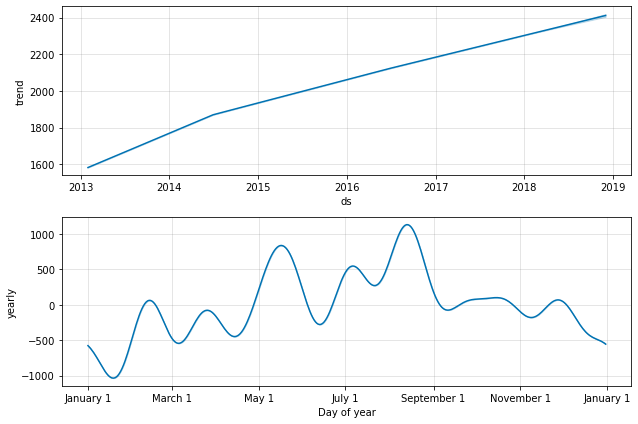

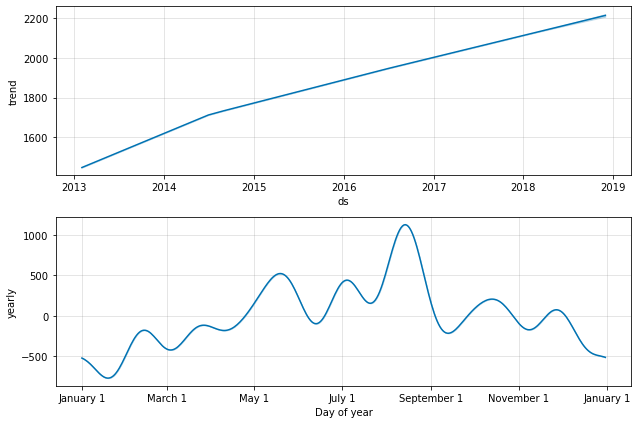

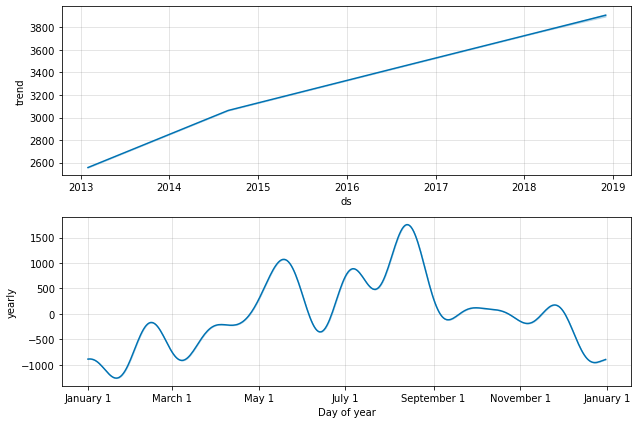

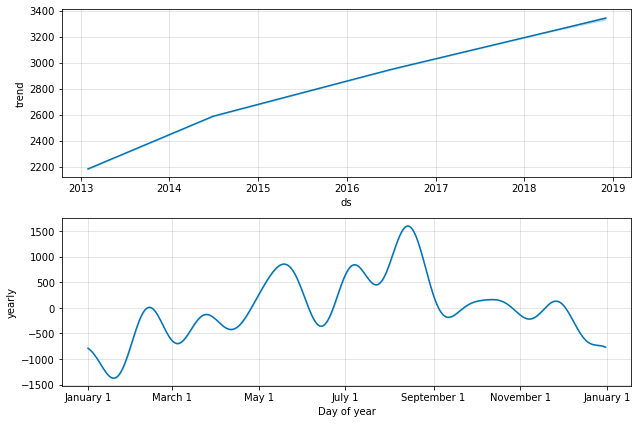

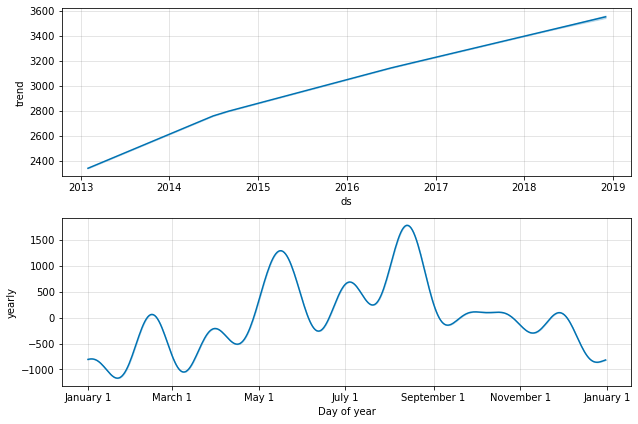

In [16]:

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_df = store_i.to_frame()
    store_i_df['ds'] = store_i_df.index
    store_i_df.columns = ['y','ds']
    store_i_model = Prophet(yearly_seasonality=True)
    store_i_model.fit(store_i_df)
    store_i_future = store_i_model.make_future_dataframe(periods=12,freq='MS')
    #store_i_future
    store_i_forecast = store_i_model.predict(store_i_future)
    #store_i_forecast
    store_i_model.plot_components(store_i_forecast);

In [22]:

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_df = store_i.to_frame()
    store_i_df['ds'] = store_i_df.index
    store_i_df.columns = ['y','ds']
    store_i_model = Prophet(yearly_seasonality=True)
    store_i_model.fit(store_i_df)
    store_i_future = store_i_model.make_future_dataframe(periods=12,freq='MS')
    #store_i_future
    store_i_forecast = store_i_model.predict(store_i_future)
    #store_i_forecast
    plot_components_plotly(store_i_model , store_i_forecast)
    

17:16:32 - cmdstanpy - INFO - Chain [1] start processing
17:16:33 - cmdstanpy - INFO - Chain [1] done processing
17:16:33 - cmdstanpy - INFO - Chain [1] start processing
17:16:34 - cmdstanpy - INFO - Chain [1] done processing
17:16:34 - cmdstanpy - INFO - Chain [1] start processing
17:16:34 - cmdstanpy - INFO - Chain [1] done processing
17:16:35 - cmdstanpy - INFO - Chain [1] start processing
17:16:35 - cmdstanpy - INFO - Chain [1] done processing
17:16:35 - cmdstanpy - INFO - Chain [1] start processing
17:16:36 - cmdstanpy - INFO - Chain [1] done processing
17:16:36 - cmdstanpy - INFO - Chain [1] start processing
17:16:37 - cmdstanpy - INFO - Chain [1] done processing
17:16:37 - cmdstanpy - INFO - Chain [1] start processing
17:16:37 - cmdstanpy - INFO - Chain [1] done processing
17:16:38 - cmdstanpy - INFO - Chain [1] start processing
17:16:38 - cmdstanpy - INFO - Chain [1] done processing
17:16:38 - cmdstanpy - INFO - Chain [1] start processing
17:16:39 - cmdstanpy - INFO - Chain [1]